# OPUS End-to-End CSTR Simulation

This notebook demonstrates the current deterministic capabilities of **OPUS (Open Process Uncertainty Simulator)** using a non-isothermal continuous stirred-tank reactor (CSTR).

The example covers the complete workflow:

1. Define validated physical process parameters.
2. Define a reproducible numerical simulation configuration.
3. Construct the CSTR model and ODE solver.
4. Run the dynamic simulation.
5. inspect solver diagnostics and state trajectories.
6. Calculate engineering performance metrics.
7. Verify the final mass and energy balances.
8. serialize the simulation inputs for reproducibility.

The reactor contains a single reactant undergoing an irreversible, first-order, exothermic reaction:

\[
A \rightarrow \text{products}
\]

The model includes feed convection, reaction consumption, reaction heat generation, and jacket heat transfer.

## 1. Environment setup

Run this notebook from the root directory of the OPUS repository.

The recommended project layout is:

```text
opus/
├── pyproject.toml
├── src/
│   └── opus/
├── tests/
└── examples/
    └── cstr_end_to_end_simulation.ipynb
```

Before opening the notebook, install OPUS in editable mode from the repository root:

```bash
python -m pip install -e .
```

This allows the notebook to import the current source code directly from `src/opus`.

In [ ]:
from dataclasses import asdict
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import opus
from opus.analysis import (
    SteadyStateTolerance,
    calculate_cstr_performance,
)
from opus.core.configuration import (
    SimulationConfiguration,
    SolverConfiguration,
    TimeConfiguration,
)
from opus.core.parameters import (
    CoolingParameters,
    FeedParameters,
    KineticParameters,
    ReactorParameters,
    SimulationParameters,
)
from opus.models.cstr import CSTR
from opus.models.state import CSTRStateIndex, ReactorState
from opus.solvers.ode_solver import ODESolver

print(f"Python executable: {sys.executable}")


print(f"OPUS imported from: {Path(opus.__file__).resolve()}")

Python executable: c:\1.projetcts\Coding\Python\OPUS\.venv\Scripts\python.exe
OPUS imported from: C:\1.projetcts\Coding\Python\OPUS\src\opus\__init__.py


## 2. Define the physical process

The example uses one internally consistent unit system:

| Quantity | Unit |
|---|---|
| Time | s |
| Volume | m³ |
| Volumetric flow rate | m³/s |
| Concentration | mol/m³ |
| Temperature | K |
| Density | kg/m³ |
| Heat capacity | J/(kg·K) |
| Activation energy | J/mol |
| Reaction enthalpy | J/mol |
| UA | W/K |
| Reaction rate | mol/(m³·s) |

OPUS currently validates values and structure, but it does not yet attach or convert physical units. Maintaining unit consistency is therefore the user's responsibility.

In [2]:
parameters = SimulationParameters(
    reactor=ReactorParameters(
        volume=1.0,
        density=1000.0,
        heat_capacity=4184.0,
        UA=500.0,
    ),
    feed=FeedParameters(
        flow_rate=1.0e-3,
        concentration=1000.0,
        temperature=300.0,
    ),
    cooling=CoolingParameters(
        coolant_temperature=295.0,
    ),
    kinetics=KineticParameters(
        k0=2.0e3,
        activation_energy=50_000.0,
        heat_of_reaction=-50_000.0,
        gas_constant=8.314462618,
    ),
)

parameters

SimulationParameters(reactor=ReactorParameters(volume=1.0, density=1000.0, heat_capacity=4184.0, UA=500.0), feed=FeedParameters(flow_rate=0.001, concentration=1000.0, temperature=300.0), cooling=CoolingParameters(coolant_temperature=295.0), kinetics=KineticParameters(k0=2000.0, activation_energy=50000.0, heat_of_reaction=-50000.0, gas_constant=8.314462618))

## 3. Define the numerical experiment

The numerical configuration is kept separate from the physical parameters.

This distinction is useful because:

- `SimulationParameters` describes the physical system.
- `SimulationConfiguration` describes how the numerical experiment is executed.

The example uses the implicit `BDF` integrator because non-isothermal reactor models can become stiff.

In [3]:
configuration = SimulationConfiguration(
    time=TimeConfiguration(
        initial_time=0.0,
        final_time=20_000.0,
        number_of_evaluation_points=2001,
    ),
    solver=SolverConfiguration(
        method="BDF",
        relative_tolerance=1.0e-9,
        absolute_tolerance=1.0e-11,
        max_step=10.0,
    ),
    initial_state=ReactorState(
        concentration=500.0,
        temperature=310.0,
    ),
)

configuration

SimulationConfiguration(time=TimeConfiguration(initial_time=0.0, final_time=20000.0, number_of_evaluation_points=2001), solver=SolverConfiguration(method='BDF', relative_tolerance=1e-09, absolute_tolerance=1e-11, max_step=10.0), initial_state=ReactorState(concentration=500.0, temperature=310.0))

### Reconstruct the configuration from serialized data

A reproducible simulation configuration should survive serialization and reconstruction without changing its values.

In [4]:
serialized_configuration = configuration.model_dump(mode="json")

restored_configuration = SimulationConfiguration.model_validate(
    serialized_configuration
)

assert restored_configuration == configuration

pd.json_normalize(serialized_configuration, sep=".").T.rename(
    columns={0: "value"}
)

,value
time.initial_time,0.0
time.final_time,20000.0
time.number_of_evaluation_points,2001
solver.method,BDF
solver.relative_tolerance,0.0
solver.absolute_tolerance,0.0
solver.max_step,10.0
initial_state.concentration,500.0
initial_state.temperature,310.0


## 4. Construct the model and solver

The current OPUS architecture deliberately keeps the model and numerical solver separate.

The CSTR implements the `DynamicModel` protocol, while `ODESolver` only requires a compatible `rhs(t, y)` method.

In [5]:
reactor = CSTR(parameters)

solver = ODESolver(
    method=configuration.solver.method,
    relative_tolerance=configuration.solver.relative_tolerance,
    absolute_tolerance=configuration.solver.absolute_tolerance,
    max_step=configuration.solver.resolved_max_step,
)

reactor, solver

(<opus.models.cstr.CSTR at 0x22690341e80>,
 ODESolver(method='BDF', relative_tolerance=1e-09, absolute_tolerance=1e-11, max_step=10.0))

## 5. Run the dynamic simulation

In [6]:
result = solver.solve(
    model=reactor,
    initial_state=configuration.initial_state.to_vector(),
    time_span=configuration.time_span,
    evaluation_times=configuration.evaluation_times,
)

assert result.success, result.message

### Solver summary

In [7]:
solver_summary = pd.DataFrame(
    {
        "Value": [
            result.success,
            result.message,
            result.nfev,
            result.njev,
            result.nlu,
            result.number_of_time_points,
            result.number_of_states,
            result.final_time,
        ]
    },
    index=[
        "Success",
        "Message",
        "Function evaluations",
        "Jacobian evaluations",
        "LU decompositions",
        "Time points",
        "State variables",
        "Final time [s]",
    ],
)

solver_summary

,Value
Success,True
Message,The solver successfully reached the end of the...
Function evaluations,4038
Jacobian evaluations,1
LU decompositions,390
Time points,2001
State variables,2
Final time [s],20000.0


## 6. Inspect the state trajectories

In [8]:
concentration = result.state_trajectory(
    CSTRStateIndex.CONCENTRATION
)
temperature = result.state_trajectory(
    CSTRStateIndex.TEMPERATURE
)

residence_time = (
    parameters.reactor.volume
    / parameters.feed.flow_rate
)
dimensionless_time = result.time / residence_time

trajectory_table = pd.DataFrame(
    {
        "time_s": result.time,
        "residence_times": dimensionless_time,
        "concentration_mol_m3": concentration,
        "temperature_K": temperature,
    }
)

trajectory_table.head()

,time_s,residence_times,concentration_mol_m3,temperature_K
0,0.0,0.00,500.000000,310.000000
1,10.0,0.01,504.937622,309.883180
2,20.0,0.02,509.826021,309.767661
3,30.0,0.03,514.665689,309.653429
4,40.0,0.04,519.457119,309.540470


### Reactant concentration response

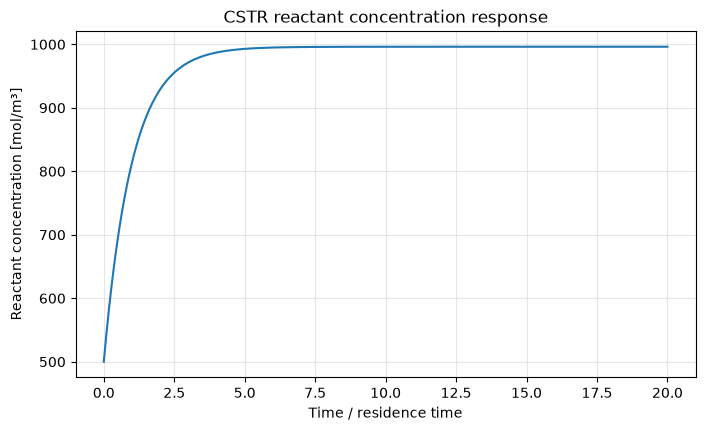

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(dimensionless_time, concentration)
ax.set_xlabel("Time / residence time")
ax.set_ylabel("Reactant concentration [mol/m³]")
ax.set_title("CSTR reactant concentration response")
ax.grid(True, alpha=0.3)

plt.show()

### Reactor temperature response

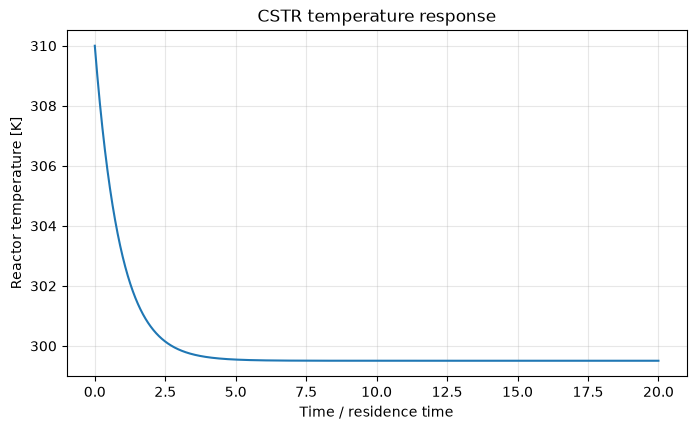

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(dimensionless_time, temperature)
ax.set_xlabel("Time / residence time")
ax.set_ylabel("Reactor temperature [K]")
ax.set_title("CSTR temperature response")
ax.grid(True, alpha=0.3)

plt.show()

## 7. Calculate engineering performance metrics

The performance layer converts raw state trajectories into engineering quantities suitable for reports, comparisons, and future uncertainty analysis.

In [11]:
metrics = calculate_cstr_performance(
    model=reactor,
    result=result,
    steady_state_tolerance=SteadyStateTolerance(
        concentration=1.0e-7,
        temperature=1.0e-7,
    ),
)

metrics

CSTRPerformanceMetrics(residence_time=1000.0, simulated_residence_times=20.0, initial_concentration=500.0, final_concentration=996.2030138333495, feed_concentration=1000.0, final_conversion=0.0037969861666505267, initial_temperature=310.0, final_temperature=299.5067995873674, minimum_temperature=299.5067995873674, maximum_temperature=310.0, time_of_maximum_temperature=0.0, final_reaction_rate=0.0037969851772454966, final_reactant_consumption_rate=0.0037969851772454966, final_reaction_heat_rate=189.84925886227484, maximum_reaction_heat_rate=196.47585275473722, final_cooling_duty=2253.3997936837122, peak_cooling_duty=7500.0, final_concentration_derivative=9.894050301273438e-10, final_temperature_derivative=-1.999699668006616e-12, concentration_balance_residual=9.894050301273438e-10, energy_balance_residual=-1.999699668006616e-12, is_steady_state=True)

In [12]:
metrics_dict = asdict(metrics)

metric_units = {
    "residence_time": "s",
    "simulated_residence_times": "-",
    "initial_concentration": "mol/m³",
    "final_concentration": "mol/m³",
    "feed_concentration": "mol/m³",
    "final_conversion": "-",
    "initial_temperature": "K",
    "final_temperature": "K",
    "minimum_temperature": "K",
    "maximum_temperature": "K",
    "time_of_maximum_temperature": "s",
    "final_reaction_rate": "mol/(m³·s)",
    "final_reactant_consumption_rate": "mol/s",
    "final_reaction_heat_rate": "W",
    "maximum_reaction_heat_rate": "W",
    "final_cooling_duty": "W",
    "peak_cooling_duty": "W",
    "final_concentration_derivative": "mol/(m³·s)",
    "final_temperature_derivative": "K/s",
    "concentration_balance_residual": "mol/(m³·s)",
    "energy_balance_residual": "K/s",
    "is_steady_state": "-",
}

metric_groups = {
    "residence_time": "Hydraulics",
    "simulated_residence_times": "Hydraulics",
    "initial_concentration": "Concentration and conversion",
    "final_concentration": "Concentration and conversion",
    "feed_concentration": "Concentration and conversion",
    "final_conversion": "Concentration and conversion",
    "initial_temperature": "Thermal response",
    "final_temperature": "Thermal response",
    "minimum_temperature": "Thermal response",
    "maximum_temperature": "Thermal response",
    "time_of_maximum_temperature": "Thermal response",
    "final_reaction_rate": "Reaction performance",
    "final_reactant_consumption_rate": "Reaction performance",
    "final_reaction_heat_rate": "Heat duties",
    "maximum_reaction_heat_rate": "Heat duties",
    "final_cooling_duty": "Heat duties",
    "peak_cooling_duty": "Heat duties",
    "final_concentration_derivative": "Steady-state diagnostics",
    "final_temperature_derivative": "Steady-state diagnostics",
    "concentration_balance_residual": "Steady-state diagnostics",
    "energy_balance_residual": "Steady-state diagnostics",
    "is_steady_state": "Steady-state diagnostics",
}

metrics_table = pd.DataFrame(
    {
        "Group": [metric_groups[name] for name in metrics_dict],
        "Metric": [
            name.replace("_", " ").title()
            for name in metrics_dict
        ],
        "Value": list(metrics_dict.values()),
        "Unit": [metric_units[name] for name in metrics_dict],
    }
)

metrics_table

,Group,Metric,Value,Unit
0,Hydraulics,Residence Time,1000.0,s
1,Hydraulics,Simulated Residence Times,20.0,-
2,Concentration and conversion,Initial Concentration,500.0,mol/m³
3,Concentration and conversion,Final Concentration,996.203014,mol/m³
4,Concentration and conversion,Feed Concentration,1000.0,mol/m³
5,Concentration and conversion,Final Conversion,0.003797,-
6,Thermal response,Initial Temperature,310.0,K
7,Thermal response,Final Temperature,299.5068,K
8,Thermal response,Minimum Temperature,299.5068,K
9,Thermal response,Maximum Temperature,310.0,K


### Compact engineering summary

In [13]:
engineering_summary = pd.DataFrame(
    {
        "Value": [
            metrics.residence_time,
            metrics.simulated_residence_times,
            metrics.final_conversion,
            metrics.final_concentration,
            metrics.final_temperature,
            metrics.maximum_temperature,
            metrics.final_reaction_heat_rate,
            metrics.final_cooling_duty,
            metrics.is_steady_state,
        ],
        "Unit": [
            "s",
            "-",
            "-",
            "mol/m³",
            "K",
            "K",
            "W",
            "W",
            "-",
        ],
    },
    index=[
        "Residence time",
        "Simulated residence times",
        "Final conversion",
        "Final concentration",
        "Final temperature",
        "Maximum temperature",
        "Final reaction heat rate",
        "Final cooling duty",
        "Steady state reached",
    ],
)

engineering_summary

,Value,Unit
Residence time,1000.0,s
Simulated residence times,20.0,-
Final conversion,0.003797,-
Final concentration,996.203014,mol/m³
Final temperature,299.5068,K
Maximum temperature,310.0,K
Final reaction heat rate,189.849259,W
Final cooling duty,2253.399794,W
Steady state reached,True,-


## 8. Verify the final mass and energy balances

The final derivative returned by the CSTR is independently reconstructed from the process equations.

For the reactant balance:

\[
\frac{dC_A}{dt}
=
\frac{F}{V}(C_{A,f}-C_A)-r_A
\]

For the energy balance:

\[
\frac{dT}{dt}
=
\frac{F}{V}(T_f-T)
+
\frac{-\Delta H\,r_A}{\rho C_p}
-
\frac{UA(T-T_c)}{\rho C_pV}
\]

In [14]:
final_concentration = metrics.final_concentration
final_temperature = metrics.final_temperature

kinetics = parameters.kinetics
reactor_parameters = parameters.reactor
feed = parameters.feed
cooling = parameters.cooling

final_rate_constant = kinetics.k0 * np.exp(
    -kinetics.activation_energy
    / (kinetics.gas_constant * final_temperature)
)

final_reaction_rate = (
    final_rate_constant * final_concentration
)

independent_mass_rhs = (
    feed.flow_rate
    / reactor_parameters.volume
    * (feed.concentration - final_concentration)
    - final_reaction_rate
)

independent_energy_rhs = (
    feed.flow_rate
    / reactor_parameters.volume
    * (feed.temperature - final_temperature)
    + (
        -kinetics.heat_of_reaction
        * final_reaction_rate
        / (
            reactor_parameters.density
            * reactor_parameters.heat_capacity
        )
    )
    - (
        reactor_parameters.UA
        * (final_temperature - cooling.coolant_temperature)
        / (
            reactor_parameters.density
            * reactor_parameters.heat_capacity
            * reactor_parameters.volume
        )
    )
)

model_rhs = reactor.rhs(
    result.final_time,
    result.final_state,
)

balance_check = pd.DataFrame(
    {
        "Independent reconstruction": [
            independent_mass_rhs,
            independent_energy_rhs,
        ],
        "CSTR.rhs": [
            model_rhs[CSTRStateIndex.CONCENTRATION],
            model_rhs[CSTRStateIndex.TEMPERATURE],
        ],
        "Absolute difference": [
            abs(
                independent_mass_rhs
                - model_rhs[CSTRStateIndex.CONCENTRATION]
            ),
            abs(
                independent_energy_rhs
                - model_rhs[CSTRStateIndex.TEMPERATURE]
            ),
        ],
        "Unit": [
            "mol/(m³·s)",
            "K/s",
        ],
    },
    index=[
        "Mass-balance derivative",
        "Energy-balance derivative",
    ],
)

balance_check

,Independent reconstruction,CSTR.rhs,Absolute difference,Unit
Mass-balance derivative,9.894050e-10,9.894050e-10,0.0,mol/(m³·s)
Energy-balance derivative,-1.999700e-12,-1.999700e-12,0.0,K/s


In [15]:
np.testing.assert_allclose(
    independent_mass_rhs,
    model_rhs[CSTRStateIndex.CONCENTRATION],
    rtol=1.0e-12,
    atol=1.0e-12,
)

np.testing.assert_allclose(
    independent_energy_rhs,
    model_rhs[CSTRStateIndex.TEMPERATURE],
    rtol=1.0e-12,
    atol=1.0e-12,
)

print("Final mass and energy balance reconstructions agree with CSTR.rhs().")

Final mass and energy balance reconstructions agree with CSTR.rhs().


## 9. Engineering interpretation

The following statements summarize the simulated reactor behavior using the calculated metrics.

In [16]:
print(
    f"The simulation covered "
    f"{metrics.simulated_residence_times:.1f} residence times."
)

print(
    f"The final outlet conversion was "
    f"{100.0 * metrics.final_conversion:.2f}%."
)

print(
    f"The reactor reached a maximum temperature of "
    f"{metrics.maximum_temperature:.2f} K."
)

print(
    f"The final cooling duty was "
    f"{metrics.final_cooling_duty:.2f} W."
)

print(
    "The final state "
    + ("satisfied" if metrics.is_steady_state else "did not satisfy")
    + " the selected steady-state derivative tolerances."
)

The simulation covered 20.0 residence times.
The final outlet conversion was 0.38%.
The reactor reached a maximum temperature of 310.00 K.
The final cooling duty was 2253.40 W.
The final state satisfied the selected steady-state derivative tolerances.


## 10. Reproducibility payload

The physical parameters and numerical configuration together define the full deterministic experiment.

At the current stage, OPUS can serialize these inputs to Python dictionaries that are ready for JSON or YAML persistence.

In [17]:
reproducibility_payload = {
    "parameters": parameters.model_dump(mode="json"),
    "configuration": configuration.model_dump(mode="json"),
}

pd.json_normalize(
    reproducibility_payload,
    sep=".",
).T.rename(columns={0: "value"})

,value
parameters.reactor.volume,1.0
parameters.reactor.density,1000.0
parameters.reactor.heat_capacity,4184.0
parameters.reactor.UA,500.0
parameters.feed.flow_rate,0.001
parameters.feed.concentration,1000.0
parameters.feed.temperature,300.0
parameters.cooling.coolant_temperature,295.0
parameters.kinetics.k0,2000.0
parameters.kinetics.activation_energy,50000.0


## 11. Current OPUS capabilities demonstrated

This notebook exercises the validated deterministic OPUS workflow:

- immutable, validated physical parameter models;
- immutable, serializable simulation configuration;
- typed reactor-state handling;
- a non-isothermal CSTR dynamic model;
- a generic SciPy-backed ODE solver;
- solver-independent simulation results;
- engineering performance calculations;
- steady-state diagnostics;
- independent final balance verification.

Parameter uncertainty, Monte Carlo sampling, statistical summaries, and sensitivity analysis are intentionally outside the scope of this example and will build on this deterministic foundation.